# Tennis Match Analysis
## Player Resilience: Who Bounces Back After Losing the First Set?

This notebook analyzes ATP tennis player resilience by measuring the win probability for players who lose the first set. We identify which players are most effective at mounting comebacks and turning matches around after early setbacks.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  



## 1. Data Loading and Inspection
Load the cleaned dataset and perform initial exploratory analysis.

In [35]:
# Load data
df = pd.read_csv('Cleaned_dataset.csv')

# Inspection
print(df.info()) # Check for missing values
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8980 entries, 0 to 8979
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pbp_id              8980 non-null   int64 
 1   date                8980 non-null   object
 2   server1             8980 non-null   object
 3   server2             8980 non-null   object
 4   winner              8980 non-null   int64 
 5   pbp                 8980 non-null   object
 6   score               8980 non-null   object
 7   wh_minutes          8980 non-null   int64 
 8   score_winner_valid  8980 non-null   bool  
 9   pbp_fixed           8980 non-null   object
 10  pbp_set_count       8980 non-null   int64 
 11  score_set_count     8980 non-null   int64 
 12  set_count_match     8980 non-null   bool  
 13  pbp_set_winners     8980 non-null   object
 14  set_match           8980 non-null   bool  
 15  pbp_match_winner    8980 non-null   int64 
 16  winner_match        8980

## 2. Feature Engineering
### Extract First Set Winner and Identify Comebacks

In [36]:
# 1. Extract the winner of the first set
def get_first_set_winner(val):
    try:
        # Convert string "[1, 2]" to an actual list [1, 2]
        winners = ast.literal_eval(val)
        return winners[0]
    except:
        return None

df['first_set_winner'] = df['pbp_set_winners'].apply(get_first_set_winner)
# 3. Mark comebacks
df['is_comeback'] = (df['first_set_winner'] != df['winner'])

## 3. Player Resilience Analysis

### Methodology
**Resilience Score** = Win percentage in matches where a player lost the first set

**Calculation Steps:**
1. Filter matches where player was either `server1` or `server2`
2. Identify matches where player lost the first set
3. Apply sample size filter (minimum 20 matches required)
4. Calculate win percentage from those matches

### Function: `calculate_resilience()`
Computes the resilience score for a given player.

In [ ]:
def calculate_resilience(player_name):
    """
    Calculate resilience score for a player.
    
    Resilience = Win % in matches where player lost Set 1
    
    Args:
        player_name (str): Name of the player
        
    Returns:
        float: Win percentage after losing first set, or None if insufficient data
    """
    # Filter all matches involving this player
    matches = df[(df['server1'] == player_name) | (df['server2'] == player_name)]
    
    # Identify matches where player lost first set
  
    lost_s1 = matches[
        ((matches['server1'] == player_name) & (matches['first_set_winner'] == 2)) | 
        ((matches['server2'] == player_name) & (matches['first_set_winner'] == 1))
    ]
    
    # Apply sample size filter
    if len(lost_s1) < 20: 
        return None  # Insufficient data
    
    # Count wins from those matches
   
    wins = lost_s1[
        ((lost_s1['server1'] == player_name) & (lost_s1['winner'] == 1)) | 
        ((lost_s1['server2'] == player_name) & (lost_s1['winner'] == 2))
    ]
    
    return (len(wins) / len(lost_s1)) * 100

## 4. Calculate Resilience Scores for Top Players

Compute resilience metrics for the 50 most active players in the dataset.

In [38]:
# Identify top 50 most active players
top_players = pd.concat([df['server1'], df['server2']]).value_counts().head(50).index

# Calculate resilience for each player
resilience_scores = {
    p: calculate_resilience(p) 
    for p in top_players 
    if calculate_resilience(p) is not None
}

print(f"Calculated resilience for {len(resilience_scores)} players")

Calculated resilience for 50 players


## 5. Visualization: Top 10 Most Resilient Players

### Horizontal Bar Chart: Resilience Rankings
This chart displays the win percentage for the top 10 most resilient players when they've lost the first set.

**Interpretation**:
- **>60% win rate**: Elite comeback ability
- **50-60% win rate**: Above average resilience
- **<50% win rate**: Struggle to recover from first set losses

**Note**: Players with <20 matches where they lost Set 1 are excluded to ensure statistical reliability.

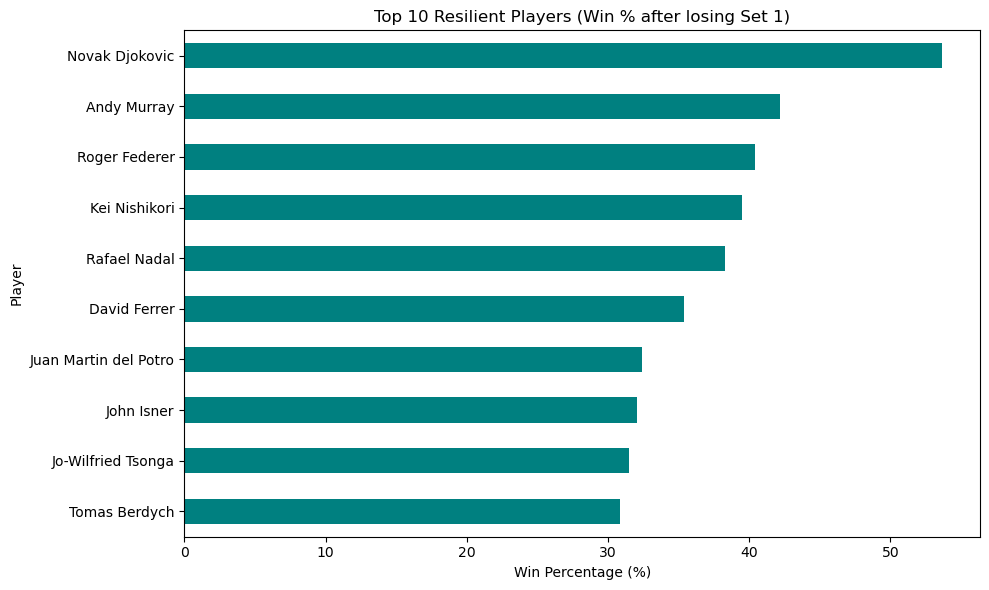

In [ ]:

res_df = pd.Series(resilience_scores).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
res_df.plot(kind='barh', color='teal', ax=ax)

ax.set_title('Top 10 Resilient Players (Win % after losing Set 1)')
ax.set_xlabel('Win Percentage (%)')
ax.set_ylabel('Player')

plt.tight_layout()
plt.savefig('visual4_resilience.png')